In [1]:
import logging
import numpy as np
from pnet.create_simulated_data import *

In [ ]:
import os
import pandas as pd
import subprocess

# Path to the perturbation summary CSV
summary_csv_path = (
    "../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut/perturbation_summary.csv"
)

# Load the perturbation summary CSV
summary_df = pd.read_csv(summary_csv_path)

# Filter the rows based on the desired conditions
filtered_df = summary_df[
    (summary_df["fraction_samples"] == 0.5)
    & (summary_df["perturb_strength"] == 1.0)
    & (summary_df["n_features"].isin(["10", "100"]))
]

# Define the perturbed data directory
perturbed_data_dir = "../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut"

# Define other parameters for the PNET model
data_config_f = "data.yaml"
evaluation_set = "validation"
model_type = "pnet"
wandb_project = "prostate_met_status"
wandb_group = "pnet_perturbed_data"
seed = 42
cpus = 8
input_data_dir = "../../pnet_germline/processed/wandb-group-data_prep_germline_tier12_and_somatic/converted-IDs-to-somatic_imputed-germline_True_imputed-somatic_False_paired-samples-True/wandb-run-id-q151d0zw"

# Iterate over the filtered rows and run the PNET model
for _, row in filtered_df.iterrows():
    perturbed_somatic_mut = os.path.basename(row["out_data_file"])  # Get the filename of the perturbed somatic_mut
    perturbed_target = os.path.basename(row["out_target_file"])  # Get the filename of the perturbed target

    # Construct the command to run the PNET model
    command = [
        "python",
        "run_model_on_perturbed_data.py",
        "--data_config_f",
        data_config_f,
        "--datasets",
        "somatic_amp somatic_del somatic_mut",
        "--evaluation_set",
        evaluation_set,
        "--model_type",
        model_type,
        "--wandb_project",
        wandb_project,
        "--wandb_group",
        wandb_group,
        "--seed",
        str(seed),
        "--input_data_dir",
        input_data_dir,
        "--perturbed_data_dir",
        perturbed_data_dir,
        "--perturbed_somatic_mut",
        perturbed_somatic_mut,
        "--perturbed_target",
        perturbed_target,
        "--cpus",
        str(cpus),
    ]
 
    # Print the command for debugging
    print(f"Running command:\n {' '.join(command)}")

Running command:
 python run_model_on_perturbed_data.py --data_config_f data.yaml --datasets somatic_amp somatic_del somatic_mut --evaluation_set validation --model_type pnet --wandb_project prostate_met_status --wandb_group pnet_perturbed_data --seed 42 --input_data_dir ../../pnet_germline/processed/wandb-group-data_prep_germline_tier12_and_somatic/converted-IDs-to-somatic_imputed-germline_True_imputed-somatic_False_paired-samples-True/wandb-run-id-q151d0zw --perturbed_data_dir ../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut --perturbed_somatic_mut somatic_mut_samplePrcnt50_features10_strengthPrcnt100.csv --perturbed_target y_samplePrcnt50_features10_strengthPrcnt100.csv --cpus 8
Running command:
 python run_model_on_perturbed_data.py --data_config_f data.yaml --datasets somatic_amp somatic_del somatic_mut --evaluation_set validation --model_type pnet --wandb_project prostate_met_status --wandb_group pnet_perturbed_data --seed 42 --input_data_dir ../../pnet

In [ ]:
 python run_model_on_perturbed_data.py --data_config_f data.yaml --datasets "somatic_amp somatic_del somatic_mut" --evaluation_set validation --model_type pnet --wandb_project prostate_met_status --wandb_group pnet_perturbed_data --seed 42 --input_data_dir ../../pnet_germline/processed/wandb-group-data_prep_germline_tier12_and_somatic/converted-IDs-to-somatic_imputed-germline_True_imputed-somatic_False_paired-samples-True/wandb-run-id-q151d0zw --perturbed_data_dir ../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut --perturbed_somatic_mut somatic_mut_samplePrcnt50_features10_strengthPrcnt100.csv --perturbed_target y_samplePrcnt50_features10_strengthPrcnt100.csv --cpus 8


Option 1: permute labels on existing data (keeps structure of gene-gene co-occurrences, other genetic structure while removing relationship with target). Goal is to address the question: “under what conditions is P-NET powered for discovery?

Steps:
Generate the "seed dataset"
1. Load data
2. Permute target labels.
Subsample to create two smaller datasets (unperturbed and perturbed). We will repeat this N=100 times.
1. Apply perturbations to the 'perturbed' dataset using a function that takes parameters to control:
    - number of samples affected
    - the number of features affected
    - the strength of the perturbation (odds ratio of case:control)


In [ ]:
# Load data
# Permute target labels
# Split data / subsample
# In each subsampled dataset:
#  

2025-01-17 19:45:16,473 - INFO - Generating original dataset...
2025-01-17 19:45:16,477 - INFO - Original dataset generated.
2025-01-17 19:45:16,478 - INFO - Calculating gene-level probabilities...
2025-01-17 19:45:16,481 - INFO - Probabilities calculated:
Gene_0    0.099
Gene_1    0.100
Gene_2    0.109
Gene_3    0.107
Gene_4    0.096
dtype: float64
2025-01-17 19:45:16,483 - INFO - Plotting probabilities: Original Gene Mutation Probabilities


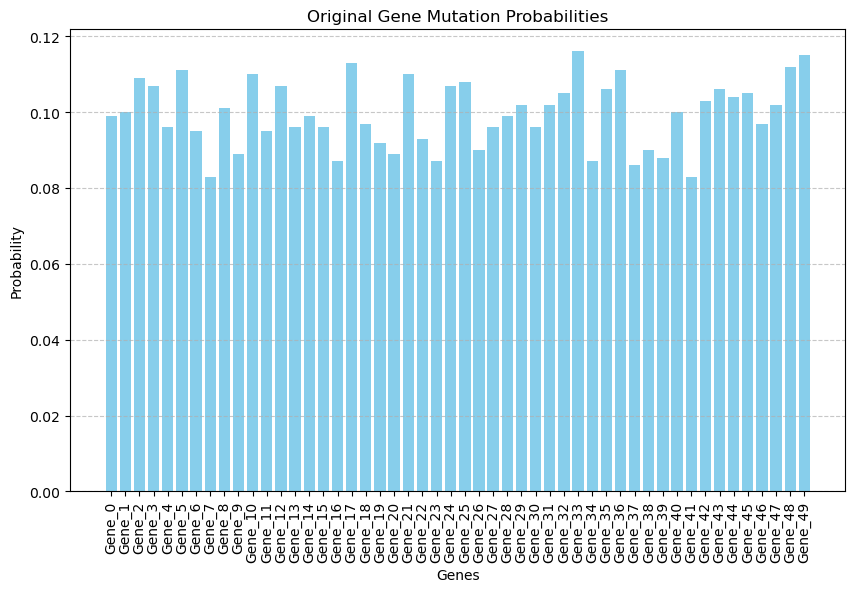

2025-01-17 19:45:17,395 - INFO - Plotting histogram: Histogram of Original Gene Mutation Probabilities


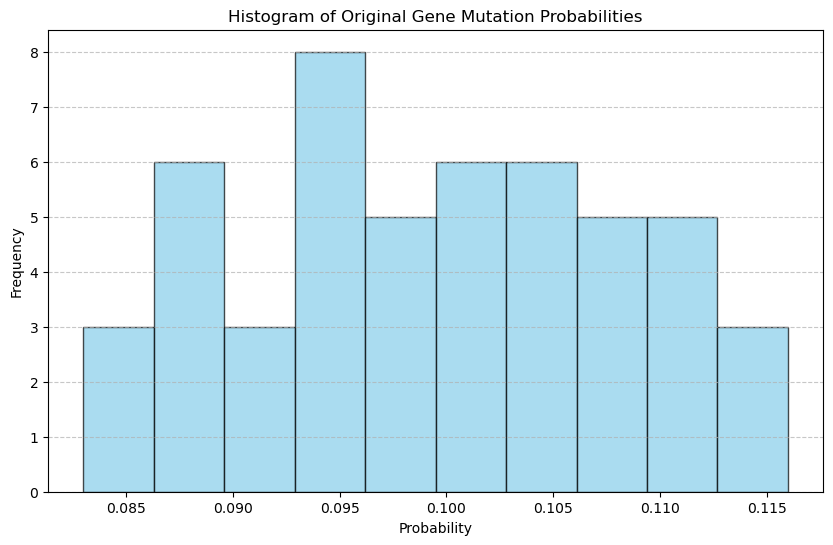

2025-01-17 19:45:17,691 - INFO - Plotting dot plot: Dot Plot of Original Gene Mutation Probabilities


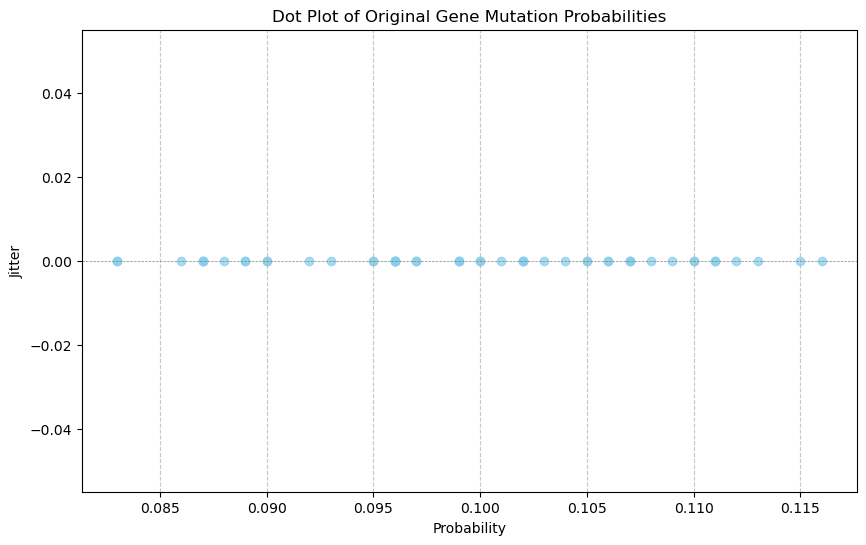

2025-01-17 19:45:17,939 - INFO - Starting perturbation process...
2025-01-17 19:45:17,940 - INFO - Calculating original probabilities...
2025-01-17 19:45:17,945 - INFO - Calculating gene-level probabilities...
2025-01-17 19:45:17,948 - INFO - Probabilities calculated:
Gene_0    0.099
Gene_1    0.100
Gene_2    0.109
Gene_3    0.107
Gene_4    0.096
dtype: float64
2025-01-17 19:45:17,949 - INFO - Perturbing 25 genes and 500 samples...
2025-01-17 19:45:17,950 - INFO - Selected genes for perturbation:
['Gene_13' 'Gene_39' 'Gene_30' 'Gene_45' 'Gene_17' 'Gene_48' 'Gene_26'
 'Gene_25' 'Gene_32' 'Gene_19' 'Gene_12' 'Gene_4' 'Gene_37' 'Gene_8'
 'Gene_3' 'Gene_6' 'Gene_41' 'Gene_46' 'Gene_47' 'Gene_15' 'Gene_9'
 'Gene_16' 'Gene_24' 'Gene_34' 'Gene_31']
2025-01-17 19:45:17,951 - INFO - Selected samples for perturbation:
[352 560 874 980  31 448 198 424 107 711 686 992 158 377 765 789 614 365
 783 932 244 843 388 824 451  59 290  70 344 184 141 978 490 660 101 746
 549 306 584 321 854 907 678 650  

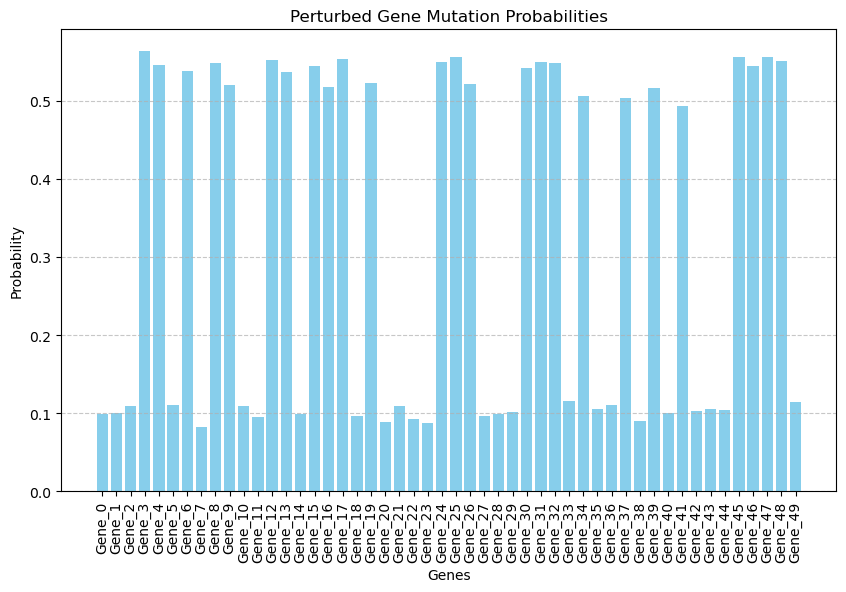

2025-01-17 19:45:18,869 - INFO - Plotting histogram: Histogram of Perturbed Gene Mutation Probabilities


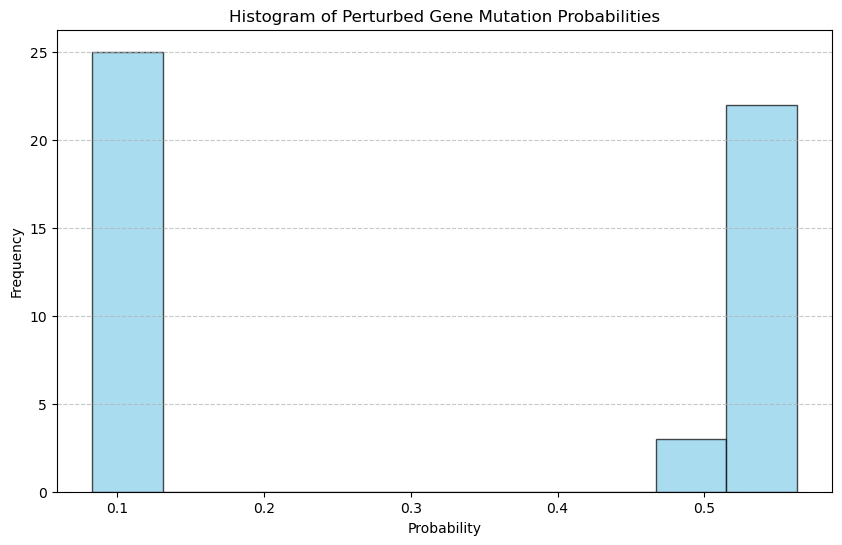

2025-01-17 19:45:19,224 - INFO - Plotting dot plot: Dot Plot of Perturbed Gene Mutation Probabilities


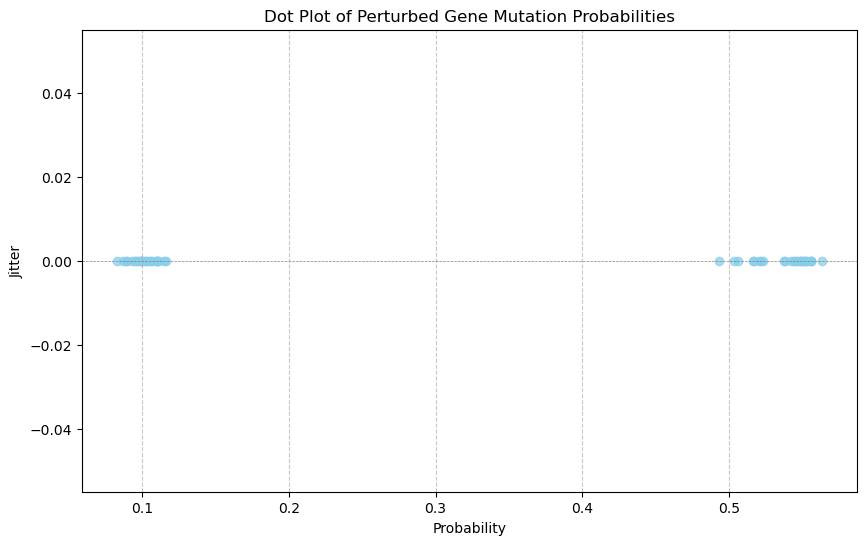

In [2]:
# Generate a toy dataset
np.random.seed(42)
logging.info("Generating original dataset...")
original_df = pd.DataFrame(np.random.binomial(1, 0.1, size=(1000, 50)), columns=[f"Gene_{i}" for i in range(50)])
logging.info("Original dataset generated.")

# Calculate probabilities
probabilities = calculate_probabilities(original_df)

# Plot probabilities
plot_probabilities(probabilities, title="Original Gene Mutation Probabilities")

# Plot histogram of probabilities
plot_probability_histogram(probabilities, bins=10, title="Histogram of Original Gene Mutation Probabilities")

# Plot dot plot of probabilities
plot_probability_dotplot(probabilities, title="Dot Plot of Original Gene Mutation Probabilities")

# Generate perturbed dataset
perturbed_df = generate_perturbed_data(
    original_df, perturb_type="shift", k=3, sample_fraction=0.5, gene_fraction=0.5
)

# Calculate and plot perturbed probabilities
perturbed_probabilities = calculate_probabilities(perturbed_df)
plot_probabilities(perturbed_probabilities, title="Perturbed Gene Mutation Probabilities")
plot_probability_histogram(
    perturbed_probabilities, bins=10, title="Histogram of Perturbed Gene Mutation Probabilities"
)
plot_probability_dotplot(perturbed_probabilities, title="Dot Plot of Perturbed Gene Mutation Probabilities")
